In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import networkx as nx
from itertools import combinations

# Read abstract information

In [2]:
DIR = "./"
df_paper = pd.read_csv(f"{DIR}/Abstracts/df_paper.txt", sep="\t")
print(df_paper.shape)
df_paper.head()

(5939, 10)


,Date,Year,Professor,PMID,title,abstract,journal,corresponding_authors,corresponding_affiliations,corresponding_countries
0,2026/6/19,2026,Hal S Alper,42112575,A Linear Mixed Effects Model for Evaluating Sy...,One significant advancement in synthetic biolo...,ACS synthetic biology,Keitz Benjamin K,"McKetta Department of Chemical Engineering, Th...",United States.
1,2025/10/17,2025,Hal S Alper,41812577,Engineering the yeast Yarrowia lipolytica for ...,The oleaginous yeast Yarrowia lipolytica has b...,Current opinion in biotechnology,Borodina Irina,The Novo Nordisk Foundation Center for Biosust...,Denmark. Electronic address: irbo@biosustain.d...
2,2025/11/6,2025,Hal S Alper,41520432,Applying a vacuum ultraviolet detector for liq...,The initial application of a prototype vacuum ...,"Journal of chromatography. B, Analytical techn...",Alper Hal S,Interdisciplinary Life Sciences Graduate Progr...,United States. Electronic address: halper@che....
3,2024/12/6,2024,Hal S Alper,41212644,Plastic degradation by enzymes from uncultured...,Polyethylene terephthalate (PET)-hydrolyzing e...,The ISME journal,Ellington Andrew D,"Department of Molecular Biosciences, The Unive...",United States.
4,2025/9/16,2025,Hal S Alper,41013967,Theranostic Probiotic Engineered Living Materi...,"The development of smart, implantable devices ...",Advanced healthcare materials,Nelson Alshakim,"Molecular Engineering and Sciences Institute, ...",USA.


# Number of papers per Professor (Figure 1)

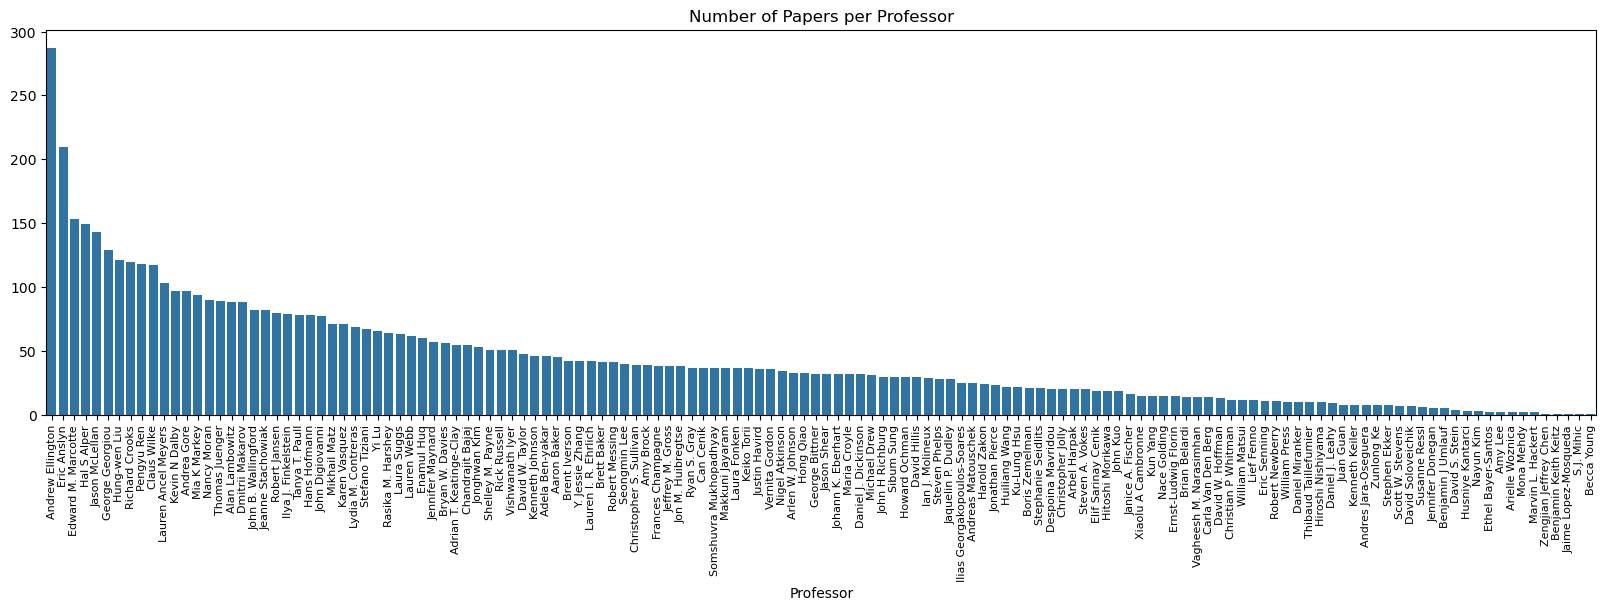

In [3]:
plt.figure(figsize=(20, 5))
sns.barplot(
    x=df_paper.Professor.value_counts().index,
    y=df_paper.Professor.value_counts().values,
    # barplot color by number of papers, Reds
    # palette=list(reversed(sns.color_palette("Grays", n_colors=len(df_paper.Professor.value_counts().values)))),
    # alpha=0.8
)
# rotate x-axis labels for better visibility
plt.xticks(rotation=90, size=8, ha="center")
plt.title("Number of Papers per Professor")
plt.savefig(
    f"{DIR}/Figures/Fig1_Number_of_Papers_per_Professor.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [4]:
pd.crosstab(df_paper.Year, df_paper.Professor)
df_plot_heatmap = pd.crosstab(df_paper.Year, df_paper.Professor)
df_plot_heatmap = df_plot_heatmap.loc[:, df_paper.Professor.value_counts().index]
print(df_plot_heatmap.shape)
df_plot_heatmap.head()

(29, 138)


Professor,Andrew Ellington,Eric Anslyn,Edward M. Marcotte,Hal S Alper,Jason McLellan,George Georgiou,Hung-wen Liu,Richard Crooks,Pengyu Ren,Claus Wilke,...,Ethel Bayer-Santos,Amy Lee,Arielle Woznica,Mona Mehdy,Marvin L. Hackert,Zengjian Jeffrey Chen,Benjamin Keith Keitz,Jaime Lopez-Mosqueda,S.J. Mihic,Becca Young
Year,,,,,,,,,,,,,,,,,,,,,
1996,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2000,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2002,10,6,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Number of papers per professor per year (Figure 2)

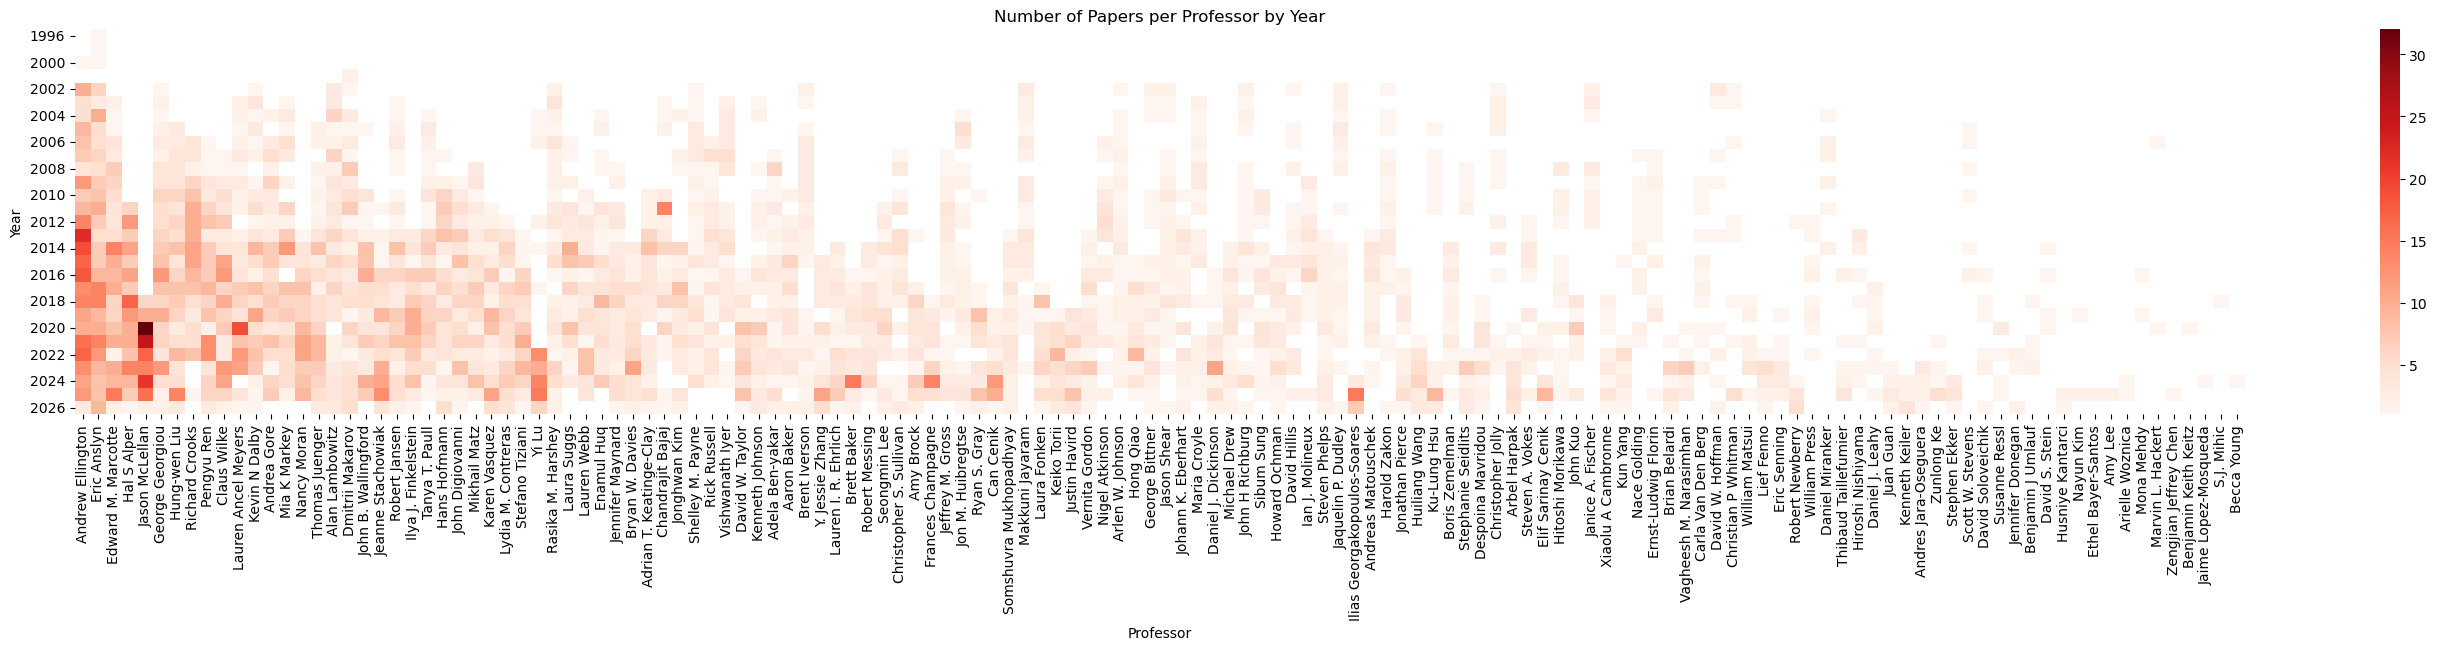

In [5]:
plt.figure(figsize=(35, 5))

sns.heatmap(
    df_plot_heatmap,
    cmap="Reds",
    annot=False,
    mask=(df_plot_heatmap == 0),
    # linewidths=0.1,
    # linecolor="lightgray",
    # cbar_kws={"label": "Number of Papers"}
)

plt.title("Number of Papers per Professor by Year")
plt.xlabel("Professor")
plt.ylabel("Year")
plt.savefig(
    f"{DIR}/Figures/Fig2_Number_of_Papers_per_Professor_by_Year.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Number of papers per professor per year, selected PIs (Figure 3)

In [6]:
# Input_1: Target professors for line plot. Default: these four professors.
target_professors = [
    "Andrew Ellington",
    "Edward M. Marcotte",
    "Jason McLellan",
    "Jennifer Maynard",
]

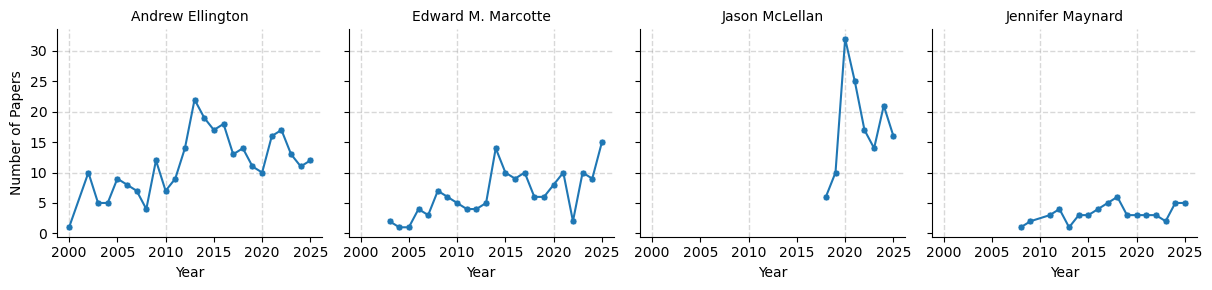

In [7]:
df_plot_line = (
    df_paper.groupby(["Professor", "Year"])
    .size()
    .reset_index(name="count")
    .sort_values(["Professor", "Year"])
)

df_plot_line = df_plot_line.loc[df_plot_line["Professor"].isin(target_professors)]


def plot_publication_trend(data, **kwargs):
    historical = data.loc[data["Year"] < 2026]
    current_year = data.loc[data["Year"] == 2026]

    # Line: only through 2025
    sns.lineplot(
        data=historical,
        x="Year",
        y="count",
        linewidth=1.5,
    )

    # Points: through 2025
    sns.scatterplot(
        data=historical,
        x="Year",
        y="count",
        s=25,
    )


g = sns.FacetGrid(
    df_plot_line,
    col="Professor",
    col_wrap=6,
    sharey=True,
    sharex=True,
    col_order=target_professors,
)

g.map_dataframe(plot_publication_trend)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Number of Papers")

plt.subplots_adjust(top=0.9)

for ax in g.axes.flatten():
    ax.tick_params(labelbottom=True)

    # Horizontal reference lines
    for y in [10, 20, 30]:
        ax.axhline(
            y=y,
            color="gray",
            linestyle="--",
            alpha=0.3,
            linewidth=1,
            zorder=0,
        )

    # Vertical reference lines
    ax.axvline(
        x=2000,
        color="gray",
        linestyle="--",
        alpha=0.3,
        linewidth=1,
        zorder=0,
    )
    ax.axvline(
        x=2010,
        color="gray",
        linestyle="--",
        alpha=0.3,
        linewidth=1,
        zorder=0,
    )
    ax.axvline(
        x=2020,
        color="gray",
        linestyle="--",
        alpha=0.3,
        linewidth=1,
        zorder=0,
    )

plt.tight_layout()

# This will be a interactively updated plot based on the "Input_1" above. Let's call this figure as Figure 3.

# Co-authorship Map based on shared PMIDs between professors.


In [8]:
def co_authorship_network(target_pi="All", background=True, fig_size=(13, 13)):
    """
    This function generates a co-authorship network for a given target principal investigator (PI).

    Parameters:
    target_pi   (str): The name of the target PI. Use "All" to include all PIs.
    background  (bool): Whether to include background nodes and edges in the visualization.
    fig_size    (tuple): The size of the figure for the network plot.

    Returns:
    None
    """

    # 1. Prepare data (Group by PMID to find co-authorship)
    df_paper["Year"] = df_paper["Year"].astype(int)

    # Calculate total paper counts per professor
    prof_paper_counts = df_paper.groupby("Professor")["PMID"].nunique().to_dict()

    # Group by PMID to get the list of professors
    pmid_groups = df_paper.groupby("PMID")["Professor"].apply(lambda x: list(set(x)))

    # Dictionary to store edge weights (count of shared PMIDs)
    edge_weights = {}

    for professors in pmid_groups:
        if len(professors) >= 2:
            # Sort to handle pairs consistently
            unique_profs = sorted(professors)
            for p1, p2 in combinations(unique_profs, 2):
                pair = (p1, p2)
                # Update edge weight
                edge_weights[pair] = edge_weights.get(pair, 0) + 1

    # 2. Initialize NetworkX Graph
    G = nx.Graph()

    # Add edges with weight attributes
    for (p1, p2), w in edge_weights.items():
        G.add_edge(p1, p2, weight=w)

    # Identify target neighbors (connected PIs)
    # Handle "All" case vs Specific PI case
    if target_pi == "All":
        target_neighbors = set()
        highlighted_nodes = set(G.nodes)  # All nodes are treated as highlighted
    else:
        if target_pi in G:
            target_neighbors = set(G.neighbors(target_pi))
            highlighted_nodes = target_neighbors | {target_pi}
        else:
            target_neighbors = set()
            highlighted_nodes = set()

    # 3. Network Layout Configuration
    plt.figure(figsize=fig_size, dpi=100)

    # spring_layout with adjusted 'k'
    pos = nx.spring_layout(G, k=0.8, iterations=100, seed=42)

    # 4. Define Visual Attributes (Filter data structures based on background flag)
    nodes_to_draw = (
        list(G.nodes) if background or target_pi == "All" else list(highlighted_nodes)
    )

    node_sizes = [15 + (prof_paper_counts.get(node, 0) * 1) for node in nodes_to_draw]

    # Define dynamic node styles
    node_colors = []
    node_alphas = []
    for node in nodes_to_draw:
        if target_pi == "All":
            node_colors.append("skyblue")  # Uniform color for overall map
            node_alphas.append(0.8)
        elif node == target_pi:
            node_colors.append("orangered")  # Highlight the central target PI
            node_alphas.append(1.0)
        elif node in target_neighbors:
            node_colors.append("skyblue")  # Highlight neighbors
            node_alphas.append(0.9)
        else:
            node_colors.append("lightgray")  # Dim unconnected nodes
            node_alphas.append(0.2)

    # Filter edges and build attributes dynamically
    edges_to_draw = []
    edge_widths = []
    edge_colors = []
    edge_alphas = []

    for u, v in G.edges:
        w = G[u][v]["weight"]
        is_highlighted_edge = target_pi == "All" or u == target_pi or v == target_pi

        if is_highlighted_edge:
            edges_to_draw.append((u, v))
            edge_widths.append(
                1.0 + (w * 1.2)
            )  # Thicker lines based on connection strength
            edge_colors.append("gray")
            edge_alphas.append(0.6 if target_pi == "All" else 0.8)
        elif background:
            # Only include non-target edges if background is True
            edges_to_draw.append((u, v))
            edge_widths.append(0.5)
            edge_colors.append("gray")
            edge_alphas.append(0.2)

    # 5. Drawing the Network Components
    # Draw Nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes_to_draw,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=node_alphas,
    )

    # Draw Edges
    for edge, w, c, a in zip(edges_to_draw, edge_widths, edge_colors, edge_alphas):
        nx.draw_networkx_edges(G, pos, edgelist=[edge], width=w, edge_color=c, alpha=a)

    # Draw Labels with dynamic styling
    pos_labels = {
        # node: (coords[0] + 0.015, coords[1] + 0.015) for node, coords in pos.items()
        node: (coords[0] + 0.005, coords[1] + 0.005)
        for node, coords in pos.items()
    }

    for node in nodes_to_draw:
        x, y = pos_labels[node]
        is_highlighted = node in highlighted_nodes

        # Handle label styling for "All" vs single PI focus
        if target_pi == "All":
            text_color = "black"
            text_size = 8
            is_bold = False
            rotation_val = 0  # No rotation needed for a standard clean overview map
        else:
            text_color = (
                "orangered"
                if node == target_pi
                else ("black" if is_highlighted else "gray")
            )
            text_size = 10 if node == target_pi else (8 if is_highlighted else 6)
            is_bold = node == target_pi
            rotation_val = 15 if is_highlighted else 0

        plt.text(
            x,
            y,
            s=node,
            fontsize=text_size,
            fontfamily="sans-serif",
            color=text_color,
            alpha=1.0 if is_highlighted else 0.25,
            weight="bold" if is_bold else "normal",
            rotation=rotation_val,
            rotation_mode="anchor",
        )

    # 6. Add Title
    title_suffix = "Overall Map" if target_pi == "All" else f"{target_pi}"
    plt.title(
        f"Co-authorship Network ({title_suffix})",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )

    # Clean up axes and show plot
    plt.axis("off")
    plt.tight_layout()
    # plt.show()

# Co-authorship network - All PIs (Figure 4)

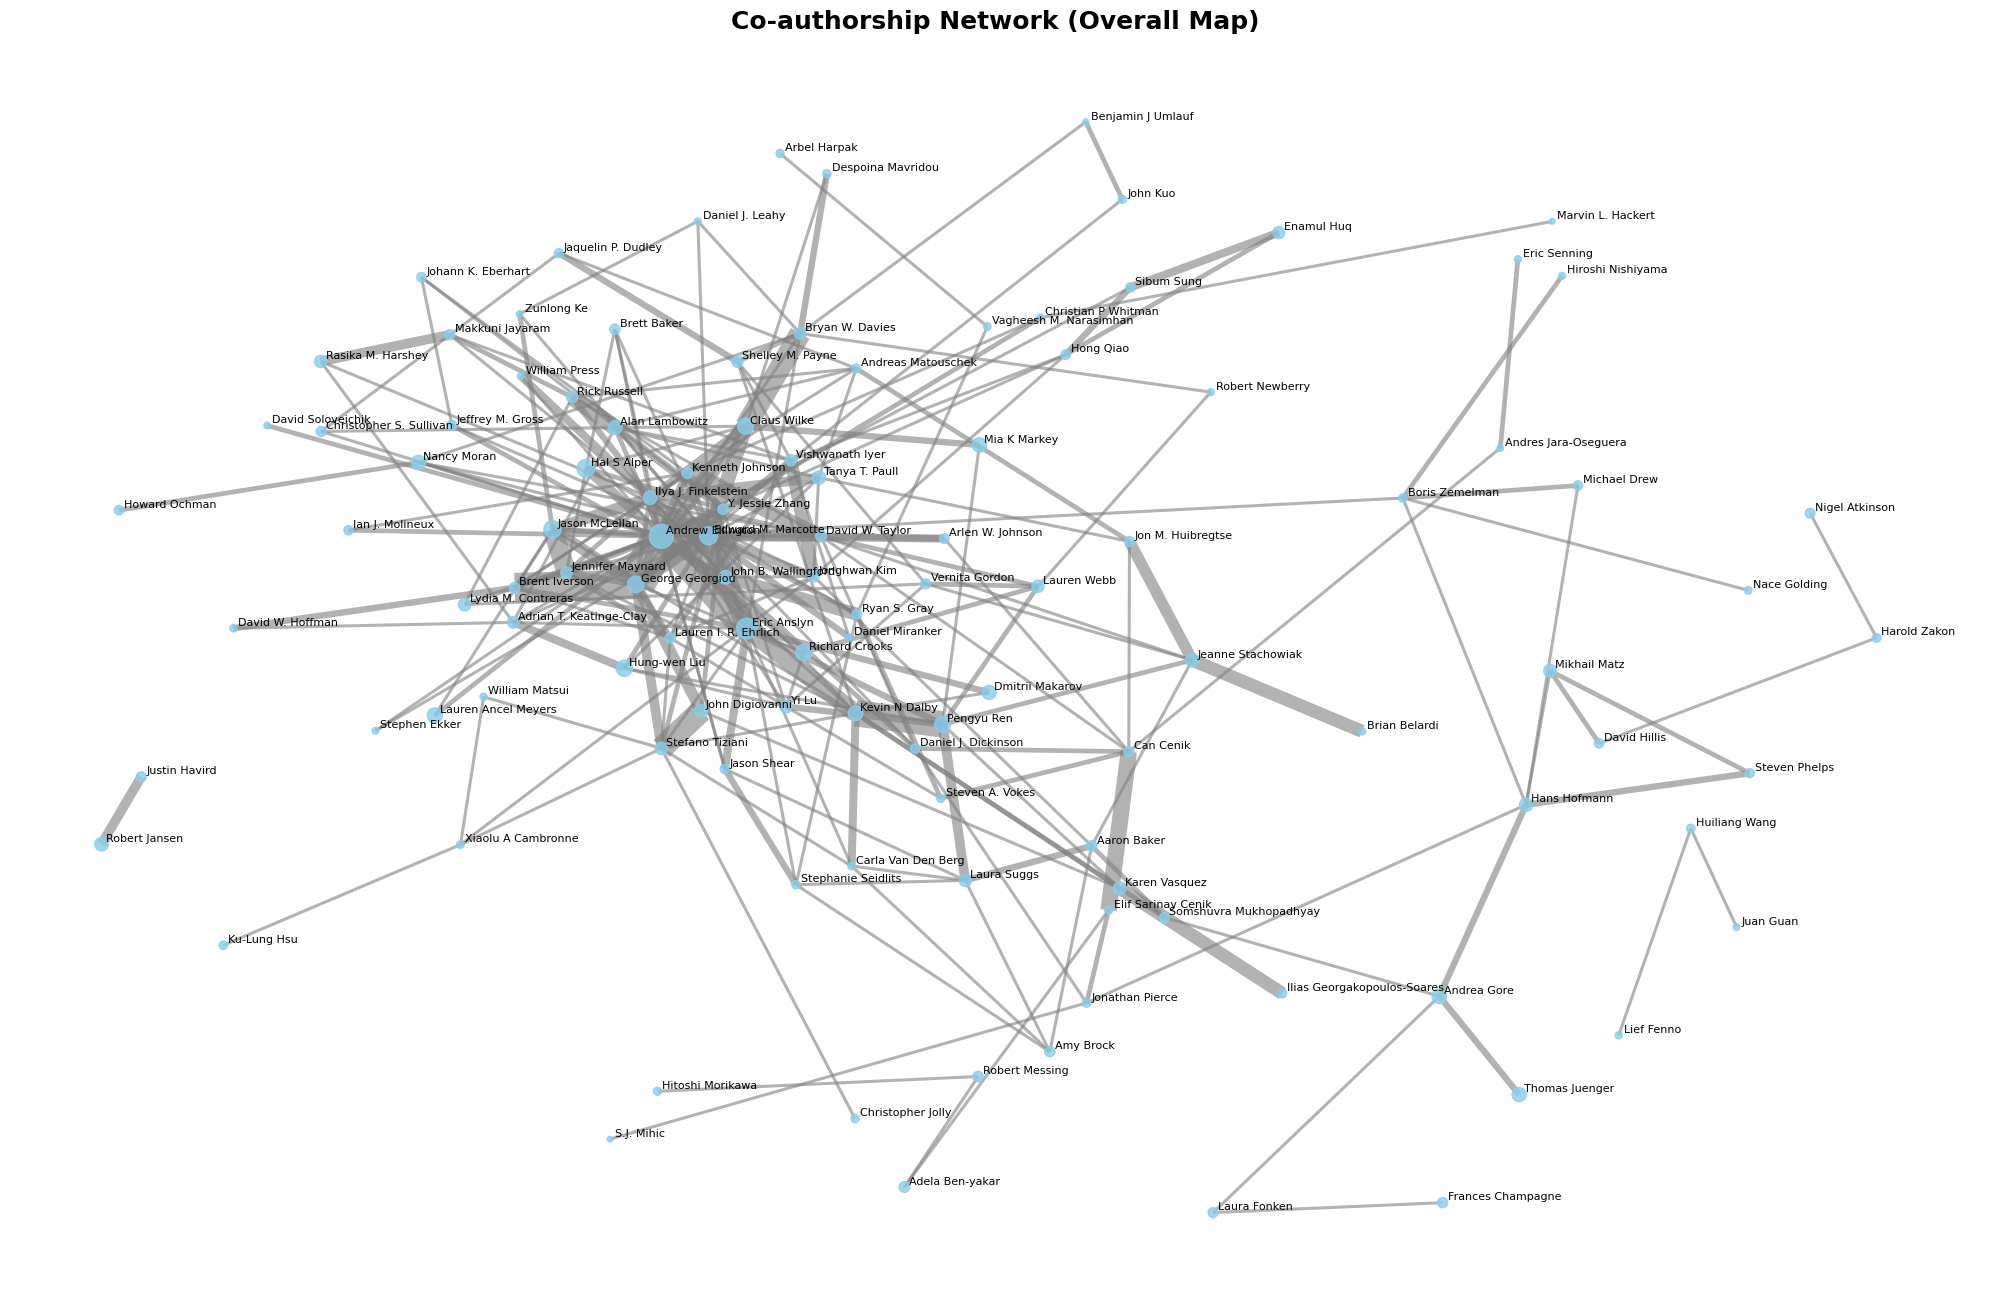

In [9]:
co_authorship_network("All", background=True, fig_size=(20, 13))
plt.savefig(
    f"{DIR}/Figures/Fig4_Co_authorship_Network_Overall_Map.png",
    dpi=300,
    bbox_inches="tight",
)

# # Co-authorship network - Selected PI (Figure 5)

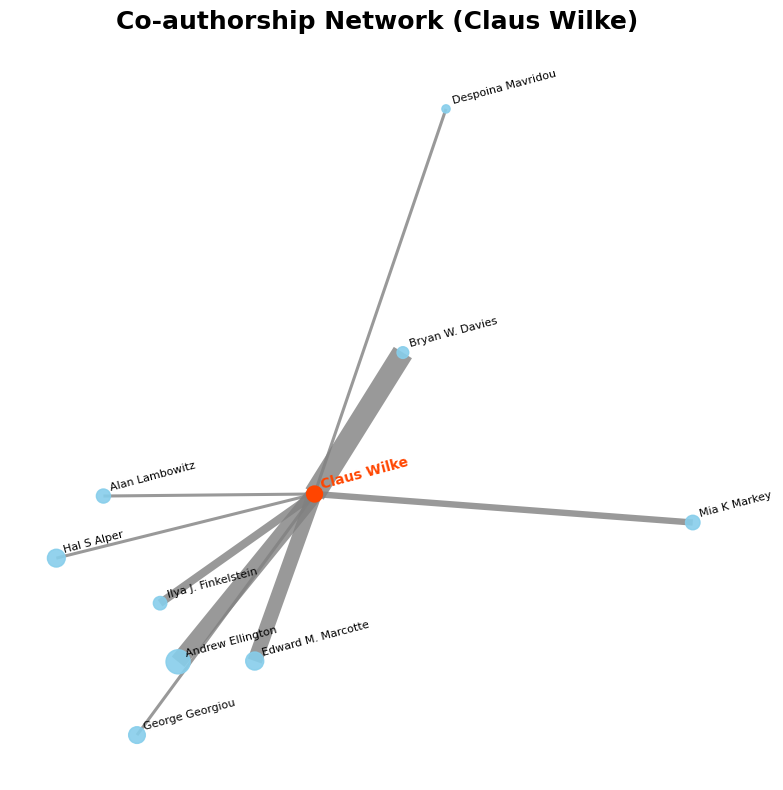

In [10]:
# Input_2: Target professor for co-authorship network. Default: "Claus Wilke"
target_professor_AuthorshipNetwork = "Claus Wilke"

# This will be a interactively updated plot based on the "Input_2" above. Let's call this figure as Figure 5.
co_authorship_network(
    target_professor_AuthorshipNetwork, background=False, fig_size=(8, 8)
)

# PI Priortization

In [11]:
import numpy as np
import pandas as pd

# import seaborn as sns
import plotly.express as px

# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

/home/tr/miniconda3/envs/find_my_lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Read paper information

# Read embeddings

In [12]:
embeddings_general = np.load(f"{DIR}/Embeddings/abstract_embeddings.npy")
print(embeddings_general.shape)
embeddings_general

(5939, 768)


array([[-0.05345295,  0.00435553, -0.0607795 , ..., -0.01164528,
        -0.00774591, -0.0051553 ],
       [ 0.04157728,  0.00616079,  0.0276549 , ..., -0.00822652,
        -0.04848148, -0.02221422],
       [ 0.04446922, -0.01687179, -0.02247425, ...,  0.0182321 ,
        -0.00314867, -0.00537071],
       ...,
       [ 0.00692969, -0.01969494, -0.00738071, ...,  0.01105603,
        -0.04215194, -0.02158257],
       [ 0.01106379, -0.03871179,  0.02449707, ..., -0.00849058,
         0.01672681, -0.00491789],
       [ 0.00205809,  0.03087081,  0.0172908 , ..., -0.05242693,
        -0.07371829,  0.00792813]], shape=(5939, 768), dtype=float32)

In [13]:
# Set the GPU device to use (if available)
# gpu = 0
# os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu)

### all-mpnet-base-v2 (https://huggingface.co/sentence-transformers/all-mpnet-base-v2)

In [14]:
# model_general = SentenceTransformer("all-mpnet-base-v2", device="cuda")
model_general = SentenceTransformer("all-mpnet-base-v2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2063.39it/s]


# Search my research interest.

In [15]:
# Input_3: Your research interest. Define your research interest. It can be short keywords or some sentences, up to ~300 words. Default: "protein language models, deep learning, structural biology, drug discovery"
my_interest = [
    # "cancer, machine learning, genome, transcriptome, computational biology",
    "protein language models, deep learning, structural biology, drug discovery",
]

# Generate embedding for your research interest
my_interest_embedding = model_general.encode(
    my_interest,
    show_progress_bar=False,  # device="cuda"
)

# Top N most similar papers, regardless of professor (Table 1)

In [16]:
# Find the closest papers to my research interest

# Input_4: Filter papers by year. Keep papers published in or after this year. Default: 2020
year_filter = 2020

# Input_5: Number of top papers used for priority ranking. Default: 20
TopN_papers = 20


similarities = cosine_similarity(my_interest_embedding, embeddings_general)
df_paper["similarity"] = similarities.flatten()

top_papers = (
    df_paper.loc[df_paper.Year >= year_filter]
    .sort_values(by="similarity", ascending=False)
    .head(TopN_papers)
    .copy()
)
top_papers.reset_index(drop=True, inplace=True)

Table_1 = top_papers[
    ["Date", "PMID", "Professor", "similarity", "title", "journal"]
].copy()

print(Table_1.to_markdown())

|    | Date       |     PMID | Professor          |   similarity | title                                                                                                   | journal                                      |
|---:|:-----------|---------:|:-------------------|-------------:|:--------------------------------------------------------------------------------------------------------|:---------------------------------------------|
|  0 | 2023/3/31  | 36993648 | Andrew Ellington   |     0.742586 | Two sequence- and two structure-based ML models have learned different aspects of protein biochemistry. | bioRxiv : the preprint server for biology    |
|  1 | 2023/4/4   | 37587128 | Andrew Ellington   |     0.742586 | Two sequence- and two structure-based ML models have learned different aspects of protein biochemistry. | Scientific reports                           |
|  2 | 2023/4/4   | 37587128 | Claus Wilke        |     0.742586 | Two sequence- and two structure-based ML models have 

# Similarity grouped by professor (Table 2)

In [17]:
# Input_6: Number of top professors to display. Default: 10
TopN_PIs = 10

# Input_7: Minimum number of papers for a professor to be considered for priority ranking. Default: 5
N_papers_minimum = 5

# Input_8: Number of top N similar papers to aggregate for each priority ranking. Default: 10
TopN_papers_aggregate = 10


# Keep this as fixed value for now, but can be changed to mean, weighted sum, or max in the future
summary_score = "median"

# Keep most recent papers for better relevance
df_paper_year = df_paper.loc[df_paper["Year"] >= year_filter].copy()

# Count the number of papers for each professor
professor_paper_counts = df_paper_year.groupby("Professor").size().rename("n_papers")

eligible_professors = professor_paper_counts[
    professor_paper_counts >= N_papers_minimum
].index

df_paper_eligible = df_paper_year.loc[
    df_paper_year["Professor"].isin(eligible_professors)
].copy()

# Select the top N papers for each professor based on similarity
df_top_papers_by_professor = (
    df_paper_eligible.sort_values(
        ["Professor", "similarity"],
        ascending=[True, False],
    )
    .groupby("Professor", group_keys=False)
    .head(TopN_papers_aggregate)
)

# Measure the summary score (e.g., median) of similarity for the selected top N papers for each professor
df_paper_grouped_by_professor = df_top_papers_by_professor.groupby("Professor").agg(
    similarity=("similarity", summary_score),
    top_n_papers_aggregated=("similarity", "size"),
)

# Add the total number of papers for each professor
df_paper_grouped_by_professor["n_papers"] = professor_paper_counts

df_paper_grouped_by_professor.sort_values(
    "similarity",
    ascending=False,
    inplace=True,
)

# Display the top N professors based on the aggregated similarity score
df_paper_grouped_by_professor_TopN = df_paper_grouped_by_professor.head(TopN_PIs).copy()
df_paper_grouped_by_professor_TopN.reset_index(drop=False, inplace=True)
df_paper_grouped_by_professor_TopN = df_paper_grouped_by_professor_TopN.loc[
    :, ["Professor", "n_papers", "top_n_papers_aggregated", "similarity"]
].copy()

Table_2 = df_paper_grouped_by_professor_TopN.copy()
print(Table_2.to_markdown())

|    | Professor          |   n_papers |   top_n_papers_aggregated |   similarity |
|---:|:-------------------|-----------:|--------------------------:|-------------:|
|  0 | Claus Wilke        |         44 |                        10 |     0.70289  |
|  1 | Andrew Ellington   |         82 |                        10 |     0.604824 |
|  2 | Bryan W. Davies    |         37 |                        10 |     0.561266 |
|  3 | Edward M. Marcotte |         56 |                        10 |     0.496702 |
|  4 | Pengyu Ren         |         47 |                        10 |     0.41981  |
|  5 | Can Cenik          |         35 |                        10 |     0.387213 |
|  6 | Jason McLellan     |        127 |                        10 |     0.383462 |
|  7 | Lydia M. Contreras |         35 |                        10 |     0.371003 |
|  8 | David W. Taylor    |         39 |                        10 |     0.358747 |
|  9 | Robert Newberry    |         10 |                        10 |     0.3

# Top N professors' TopN papers (Table 3)

In [18]:
df_top_professor_topN_papers = df_top_papers_by_professor.loc[
    df_top_papers_by_professor.Professor.isin(
        df_paper_grouped_by_professor_TopN.Professor
    )
].copy()

df_top_professor_topN_papers = df_top_professor_topN_papers.merge(
    df_paper_grouped_by_professor_TopN[["Professor", "similarity"]],
    on="Professor",
    how="left",
    suffixes=("", "_median"),
)


df_top_professor_topN_papers.sort_values(
    ["similarity_median", "similarity"],
    ascending=[False, False],
    inplace=True,
)
df_top_professor_topN_papers.reset_index(drop=True, inplace=True)
df_top_professor_topN_papers = df_top_professor_topN_papers.loc[
    :,
    [
        # "Date",
        "Year",
        "PMID",
        "Professor",
        "similarity_median",
        "similarity",
        "title",
        "journal",
    ],
]

Table_3 = df_top_professor_topN_papers.copy()
print(Table_3.to_markdown())

|    |   Year |     PMID | Professor          |   similarity_median |   similarity | title                                                                                                                                                                       | journal                                                |
|---:|-------:|---------:|:-------------------|--------------------:|-------------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------------------------------------|
|  0 |   2023 | 37587128 | Claus Wilke        |            0.70289  |     0.742586 | Two sequence- and two structure-based ML models have learned different aspects of protein biochemistry.                                                                     | Scientific reports                                     |
|  1 |   2023 | 36993648 | Claus Wilke        |     

# Boxplot (Figure 6)

In [19]:
# based on the keyword above,
keyword = my_interest[0]

TopN_professors = df_paper_grouped_by_professor_TopN.Professor.values

fig = px.box(
    df_top_professor_topN_papers,
    x="similarity",
    y="Professor",
    category_orders={"Professor": TopN_professors},  # Replaces order
    points="all",  # Shows all points (like swarmplot)
    color="Professor",
    notched=False,
    hover_data=[
        "Professor",
        "title",
        "Year",
    ],  # Adds interactivity
)

# Customizing to match the 'showfliers=False' and swarm appearance
fig.update_traces(
    jitter=0.5,  # Spread the points out to look like a swarm
    pointpos=0,  # Center the points on the boxes
    marker=dict(size=5),
)

fig.update_layout(
    height=600,
    width=1000,
    showlegend=True,
    yaxis={
        "categoryorder": "array",
        "categoryarray": TopN_professors,
        "autorange": "reversed",  # <--- Add this line to flip the order
    },
)


fig.update_layout(
    height=650,
    width=1100,
    showlegend=False,
    yaxis={
        "categoryorder": "array",
        "categoryarray": TopN_professors,
        "autorange": "reversed",  # <--- Add this line to flip the order
    },
    title=f"Top {TopN_PIs} Professors by Similarity to: {keyword}",
    xaxis_title="Cosine Similarity",
    yaxis_title="Professor",
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(color="black"),
    title_font=dict(color="black"),
    hovermode="closest",
    hoverdistance=-1,
    hoverlabel=dict(
        bgcolor="rgba(255, 255, 255, 0.95)",
        font_color="black",
        align="left",
        font_size=12,
        font_family="Arial",
        bordercolor="black",
    ),
)

fig.update_xaxes(
    range=[0, 1],
    showgrid=True,
    gridcolor="lightgray",
    zeroline=False,
    linecolor="black",
    tickfont=dict(color="black"),
    title_font=dict(color="black"),
)

fig.update_yaxes(
    showgrid=False,
    linecolor="black",
    tickfont=dict(color="black"),
    title_font=dict(color="black"),
)

fig.show()

# Full list of papers for the top N professors, since Year (Table 4))

In [20]:
df_paper_year_topN_professors = df_paper_year.loc[
    df_paper_year.Professor.isin(TopN_professors), :
].copy()
df_paper_year_topN_professors = df_paper_year_topN_professors.merge(
    df_paper_grouped_by_professor_TopN[["Professor", "similarity"]],
    on="Professor",
    how="left",
    suffixes=("", "_median"),
)


df_paper_year_topN_professors = df_paper_year_topN_professors.loc[
    :,
    [
        # "Date",
        "Year",
        "PMID",
        "Professor",
        "similarity_median",
        "similarity",
        "title",
        "journal",
    ],
].copy()

df_paper_year_topN_professors = df_paper_year_topN_professors.sort_values(
    ["similarity_median", "similarity"],
    ascending=[False, False],
    inplace=False,
)

df_paper_year_topN_professors.reset_index(drop=True, inplace=True)

Table_4 = df_paper_year_topN_professors.copy()
print(Table_4.to_markdown())

|     |   Year |     PMID | Professor          |   similarity_median |   similarity | title                                                                                                                                                                                                                                                                           | journal                                                                                              |
|----:|-------:|---------:|:-------------------|--------------------:|-------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------|
|   0 |   2023 | 37587128 | Claus Wilke        |            0.70289  |    